<a href="https://colab.research.google.com/github/msmareeb/databases-and-analytics-assignment/blob/main/python_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


base_url = "https://raw.githubusercontent.com/msmareeb/databases-and-analytics-assignment/main/northstar_dataset/"

# Loading all datasets using the base_url prefix
customers = pd.read_csv(base_url + 'customers.csv')
orders = pd.read_csv(base_url + 'orders.csv')
vehicles = pd.read_csv(base_url + 'vehicles.csv')
incidents = pd.read_csv(base_url + 'incidents.csv')
hubs = pd.read_csv(base_url + 'hubs.csv')
drivers = pd.read_csv(base_url + 'drivers.csv')
deliveries = pd.read_csv(base_url + 'deliveries.csv')
data_dictionary = pd.read_csv(base_url + 'data_dictionary.csv')
complaints = pd.read_csv(base_url + 'complaints.csv')
app_events = pd.read_csv(base_url + 'app_events.csv')

# Verification: Print the first few rows of one dataframe to ensure it loaded correctly
print("Data loaded successfully!")
print(deliveries.head())

Data loaded successfully!
  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                     

In [4]:
datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "complaints": complaints,
    "drivers": drivers,
    "vehicles": vehicles,
    "incidents": incidents,
    "hubs": hubs,
    "app_events": app_events
}

for name, df in datasets.items():
    print(name, df.shape)
    print(df.head())
    print()

customers (650, 9)
  customer_id  age  home_zone customer_type          signup_date  \
0       C0001   26      North           SME  2024-11-27 04:25:00   
1       C0002   61    AIRPORT      Consumer  2025-10-28 01:04:00   
2       C0003   66       East      Consumer  2025-07-02 03:23:00   
3       C0004   75    CENTRAL      Consumer  2025-08-19 01:58:00   
4       C0005   26  Riverside      Consumer  2025-06-03 06:02:00   

   loyalty_score  app_engagement_score preferred_channel account_status  
0           44.9                  69.2               App         Active  
1           55.4                  66.6               App         Active  
2           75.9                  33.8               NaN         Active  
3           32.5                  33.0               App         Active  
4           55.9                 100.0               Web         Active  

orders (1250, 11)
  order_id customer_id service_type     order_created_at  \
0   O00001       C0292    Passenger  2024-08-20 1

In [6]:
for name, df in datasets.items():
  print(f"\n {name}")
  print("Missing values: ")
  print(df.isnull().sum())
  print("Duplicates: ", df.duplicated().sum())


 customers
Missing values: 
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64
Duplicates:  0

 orders
Missing values: 
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64
Duplicates:  0

 deliveries
Missing values: 
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km   

In [7]:
merged = orders.merge(deliveries, on="order_id", how="left")

service_status = (
    merged.groupby(["service_type", "delivery_status"])
    .size()
    .reset_index(name="count")
)

print(service_status)

   service_type delivery_status  count
0      Business         Delayed     28
1      Business          Failed     25
2      Business          OnTime     73
3       Medical         Delayed     22
4       Medical          Failed     16
5       Medical          OnTime     70
6        Parcel         Delayed     49
7        Parcel          Failed     25
8        Parcel          OnTime    156
9     Passenger         Delayed     53
10    Passenger          Failed     38
11    Passenger          OnTime    171
12       Retail         Delayed     50
13       Retail          Failed     28
14       Retail          OnTime    146


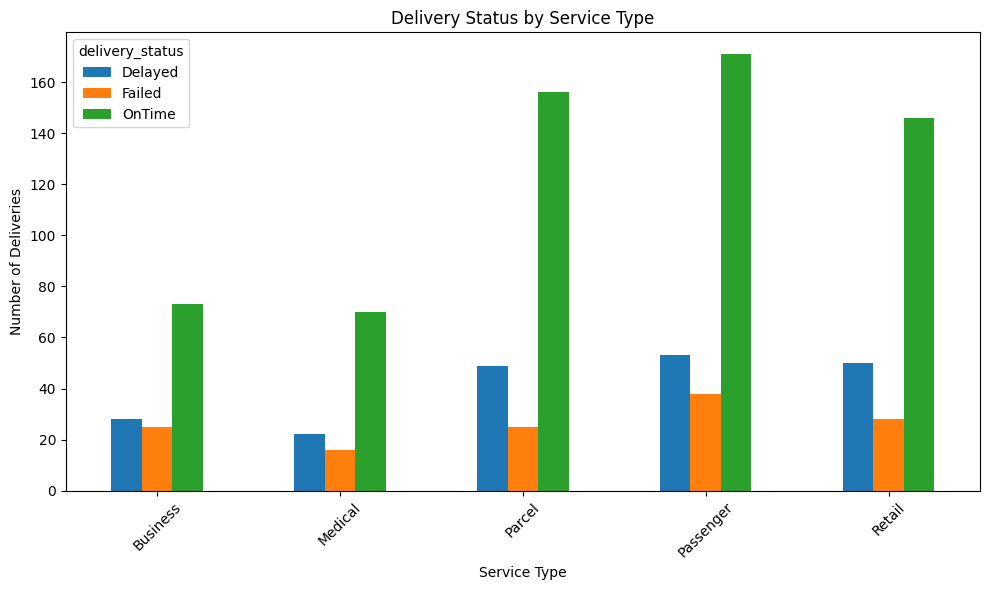

In [8]:
service_status_pivot = service_status.pivot(
    index="service_type",
    columns="delivery_status",
    values="count"
).fillna(0)

service_status_pivot.plot(kind="bar", figsize=(10, 6))

plt.title("Delivery Status by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
vehicles_analysis = (
    vehicles.groupby(["vehicle_type", "maintenance_status"])
    .size()
    .reset_index(name="count")
)

print(vehicles_analysis)

   vehicle_type maintenance_status  count
0      CargoVan             Active     14
1      CargoVan           InRepair     12
2      CargoVan          Scheduled      4
3        Diesel             Active     10
4        Diesel           InRepair      7
5        Diesel          Scheduled      2
6            EV             Active     29
7            EV           InRepair      8
8            EV          Scheduled      6
9        Hybrid             Active     14
10       Hybrid           InRepair      9
11       Hybrid          Scheduled      5


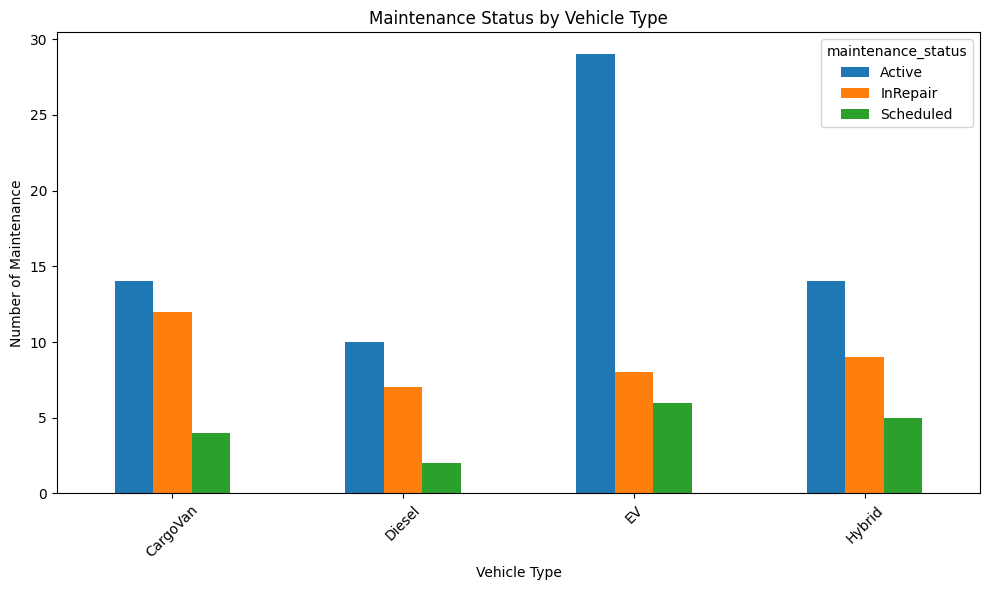

In [12]:
vehicle_pivot = vehicles_analysis.pivot(
    index = "vehicle_type",
    columns = "maintenance_status",
    values = "count"
).fillna(0)

vehicle_pivot.plot(kind="bar", figsize=(10,6))

plt.title("Maintenance Status by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Maintenance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
app_analysis = (
    app_events.groupby("success_flag")["api_latency_ms"]
    .mean()
    .reset_index()
)

print(app_analysis)

   success_flag  api_latency_ms
0             0      468.500000
1             1      465.488372


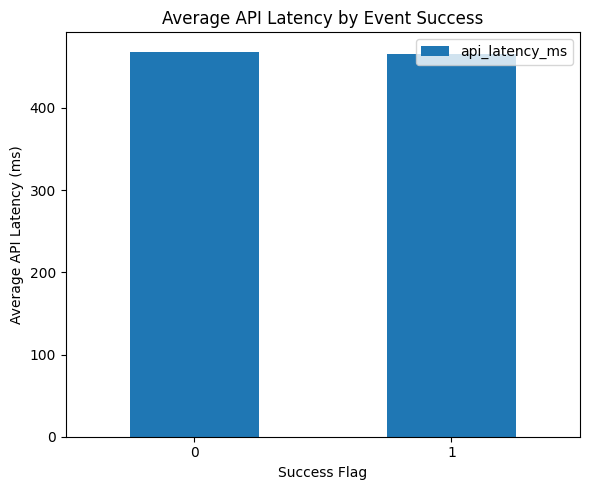

In [14]:
app_analysis.plot(
    kind="bar",
    x="success_flag",
    y="api_latency_ms",
    figsize=(6,5)
)

plt.title("Average API Latency by Event Success")
plt.xlabel("Success Flag")
plt.ylabel("Average API Latency (ms)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()